# Import Required Libraries

In [ ]:
# Numerical computation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization,
    GlobalAveragePooling2D
)

# Regularization & Initialization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import HeNormal, GlorotUniform

# Callbacks
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

# Data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Metrics
from sklearn.metrics import classification_report

# Utility
import random
import warnings

warnings.filterwarnings("ignore")

# Set Random Seed

In [ ]:
# Reproducibility

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("Random Seed Set:", SEED)

Random Seed Set: 42


# GPU Check

In [ ]:
print("TensorFlow Version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU is Available")
    print("GPU Device:", gpus[0])
else:
    print("GPU not found. Please enable GPU.")

TensorFlow Version: 2.20.0
GPU is Available
GPU Device: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


# Load CIFAR-100 Dataset + Dataset Understanding + Shape Analysis + Class Inspection + EDA

## Load CIFAR-100 Dataset

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

print("Dataset Loaded Successfully")

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Dataset Loaded Successfully


## Shape Analysis

In [ ]:
print("Training Image Shape :", x_train.shape)
print("Training Label Shape :", y_train.shape)

print("\nTesting Image Shape :", x_test.shape)
print("Testing Label Shape :", y_test.shape)

Training Image Shape : (50000, 32, 32, 3)
Training Label Shape : (50000, 1)

Testing Image Shape : (10000, 32, 32, 3)
Testing Label Shape : (10000, 1)


## Check Number of Classes

In [ ]:
num_classes = len(np.unique(y_train))

print("Total Classes:", num_classes)

Total Classes: 100


## Check Data Type and Pixel Range

In [ ]:
# Dataset Information

print("Image Data Type:", x_train.dtype)

print("\nMinimum Pixel Value:", x_train.min())
print("Maximum Pixel Value:", x_train.max())

Image Data Type: uint8

Minimum Pixel Value: 0
Maximum Pixel Value: 255


## Visualize Sample Images

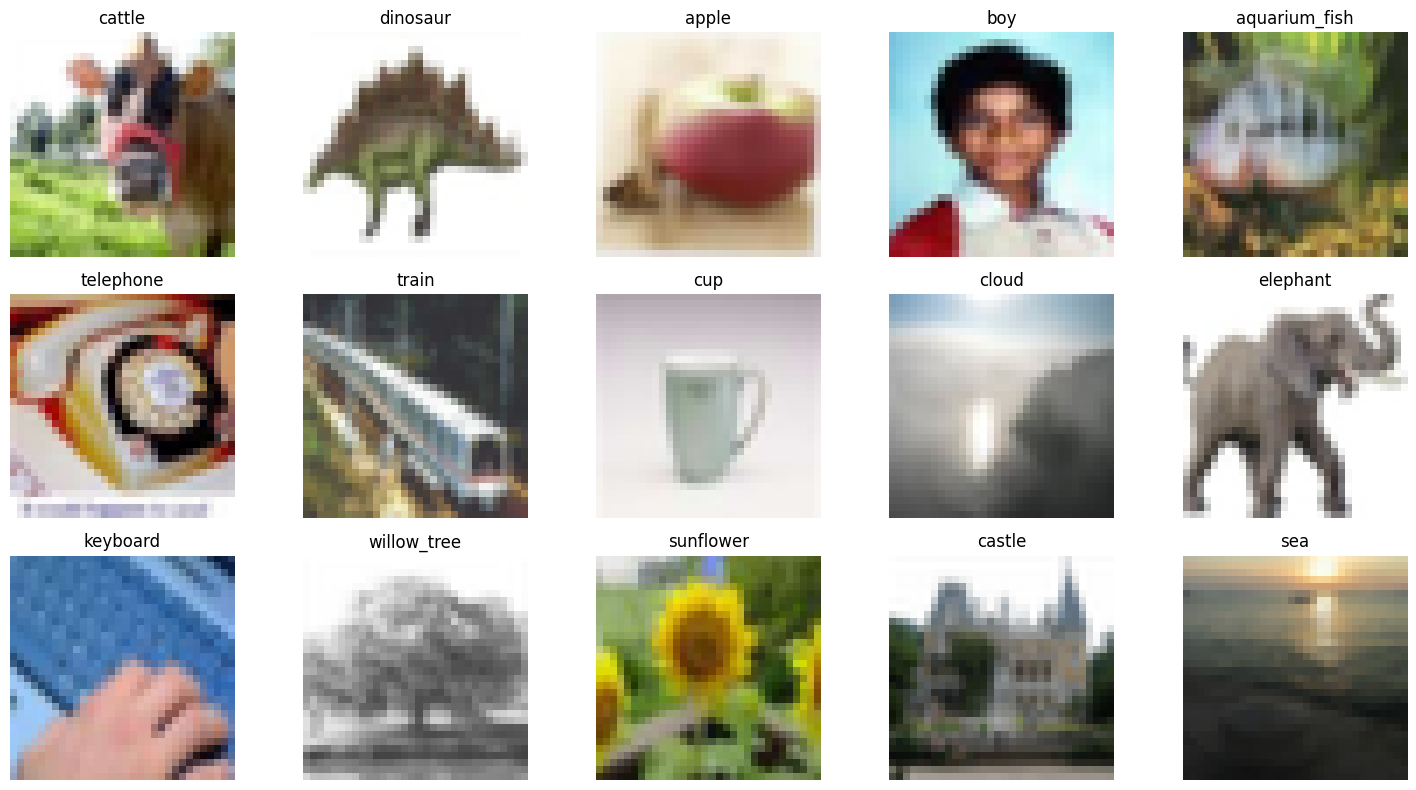

In [ ]:
class_names = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver',
    'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly',
    'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach',
    'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox',
    'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
    'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard',
    'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid',
    'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum',
    'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew',
    'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor',
    'train', 'trout', 'tulip', 'turtle', 'wardrobe',
    'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

plt.figure(figsize=(15,8))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Class Distribution Check

In [ ]:
unique_classes, counts = np.unique(y_train, return_counts=True)

print("Minimum Samples in Class:", counts.min())
print("Maximum Samples in Class:", counts.max())

Minimum Samples in Class: 500
Maximum Samples in Class: 500


### Dataset Insights

- CIFAR-100 contains 50,000 training images and 10,000 testing images.
- Each image has dimensions of 32×32 with 3 RGB channels.
- The dataset contains 100 balanced classes.
- Pixel values range between 0 and 255, requiring normalization before training.
- Since the dataset is balanced, no resampling techniques are needed.

# Data Preprocessing

Normalization + Label Encoding + Data Augmentation + Pipeline

## Normalize Image Data

In [ ]:
# Normalize Pixel Values

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Normalization Completed")

print("\nNew Pixel Range:")
print("Minimum:", x_train.min())
print("Maximum:", x_train.max())

Normalization Completed

New Pixel Range:
Minimum: 0.0
Maximum: 1.0


## One-Hot Encode Labels

In [ ]:
y_train_encoded = to_categorical(y_train, num_classes=100)
y_test_encoded = to_categorical(y_test, num_classes=100)

print("Encoded Label Shape:", y_train_encoded.shape)

Encoded Label Shape: (50000, 100)


## Create Validation Split

In [ ]:
# Create Validation Set

from sklearn.model_selection import train_test_split

x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train,
    y_train_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train
)

print("Final Training Shape:", x_train_final.shape)
print("Validation Shape:", x_val.shape)

Final Training Shape: (40000, 32, 32, 3)
Validation Shape: (10000, 32, 32, 3)


## Data Augmentation

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(x_train_final)

print("Data Augmentation Ready")

Data Augmentation Ready


## Verify Shapes After Preprocessing

In [ ]:
print("Training Images:", x_train_final.shape)
print("Validation Images:", x_val.shape)
print("Test Images:", x_test.shape)

print("\nTraining Labels:", y_train_final.shape)
print("Validation Labels:", y_val.shape)
print("Test Labels:", y_test_encoded.shape)

Training Images: (40000, 32, 32, 3)
Validation Images: (10000, 32, 32, 3)
Test Images: (10000, 32, 32, 3)

Training Labels: (40000, 100)
Validation Labels: (10000, 100)
Test Labels: (10000, 100)


# Build a Custom CNN Architecture (with dropout, batch normalization, initialization, regularization, and experimentation-ready design)

## Build Custom CNN

In [ ]:
# Custom CNN Model


custom_cnn = Sequential([


    # Block 1

    Conv2D(
        32,
        (3, 3),
        padding='same',
        activation='relu',
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(0.001),
        input_shape=(32, 32, 3)
    ),

    BatchNormalization(),

    Conv2D(
        32,
        (3, 3),
        padding='same',
        activation='relu',
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(0.001)
    ),

    BatchNormalization(),

    MaxPooling2D((2, 2)),
    Dropout(0.25),


    # Block 2

    Conv2D(
        64,
        (3, 3),
        padding='same',
        activation='relu',
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(0.001)
    ),

    BatchNormalization(),

    Conv2D(
        64,
        (3, 3),
        padding='same',
        activation='relu',
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(0.001)
    ),

    BatchNormalization(),

    MaxPooling2D((2, 2)),
    Dropout(0.30),


    # Block 3

    Conv2D(
        128,
        (3, 3),
        padding='same',
        activation='relu',
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(0.001)
    ),

    BatchNormalization(),

    Conv2D(
        128,
        (3, 3),
        padding='same',
        activation='relu',
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(0.001)
    ),

    BatchNormalization(),

    MaxPooling2D((2, 2)),
    Dropout(0.40),


    # Fully Connected Layers

    Flatten(),

    Dense(
        256,
        activation='relu',
        kernel_initializer=HeNormal()
    ),

    BatchNormalization(),
    Dropout(0.50),

    Dense(100, activation='softmax')
])

print("Custom CNN Model Created Successfully")

Custom CNN Model Created Successfully


## Model Summary

In [ ]:
custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 840,068 (3.20 MB)

 Trainable params: 838,660 (3.20 MB)

 Non-trainable params: 1,408 (5.50 KB)

### Custom CNN Architecture Design

The custom CNN was designed using multiple convolutional blocks to progressively extract low-level and high-level image features. Batch normalization was applied to stabilize training and improve convergence. Dropout and L2 regularization were used to reduce overfitting.

Architecture Highlights:
- 6 convolutional layers
- ReLU activation
- He Normal initialization
- Batch Normalization
- Dropout regularization
- L2 kernel regularization
- Softmax output layer for 100-class classification

# Compile + Callbacks (EarlyStopping & ModelCheckpoint) + Training Setup

## Compile Custom CNN

In [ ]:
custom_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Custom CNN Compiled Successfully")

Custom CNN Compiled Successfully


## Create Callbacks

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath='best_custom_cnn.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("Callbacks Created Successfully")

Callbacks Created Successfully


## Start Training

In [ ]:
# Train Custom CNN

history_custom = custom_cnn.fit(
    datagen.flow(
        x_train_final,
        y_train_final,
        batch_size=64
    ),
    validation_data=(x_val, y_val),
    epochs=50,
    callbacks=[
        early_stopping,
        model_checkpoint
    ],
    verbose=1
)

Epoch 1/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0516 - loss: 5.5606
Epoch 1: val_accuracy improved from None to 0.15100, saving model to best_custom_cnn.keras

Epoch 1: finished saving model to best_custom_cnn.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 50ms/step - accuracy: 0.0797 - loss: 5.1122 - val_accuracy: 0.1510 - val_loss: 4.3703
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1428 - loss: 4.3662
Epoch 2: val_accuracy improved from 0.15100 to 0.21980, saving model to best_custom_cnn.keras

Epoch 2: finished saving model to best_custom_cnn.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step - accuracy: 0.1567 - loss: 4.2252 - val_accuracy: 0.2198 - val_loss: 3.8032
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.2048 - loss: 3.8176
Epoch 3: val_accuracy improved from 0.21980 to 0.25360, saving model to best_custom_cnn.keras

Epoch 3: finished saving model to best_custom_cnn.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accura

# Evaluate Custom CNN + Accuracy/Loss Curves + Test Accuracy + Analysis

## Evaluate on Test Data

In [ ]:
# Evaluate Custom CNN

test_loss_custom, test_accuracy_custom = custom_cnn.evaluate(
    x_test,
    y_test_encoded,
    verbose=1
)

print("\nCustom CNN Test Accuracy:",
      round(test_accuracy_custom * 100, 2), "%")

print("Custom CNN Test Loss:",
      round(test_loss_custom, 4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4871 - loss: 2.2665

Custom CNN Test Accuracy: 48.71 %
Custom CNN Test Loss: 2.2665


## Plot Accuracy Curves

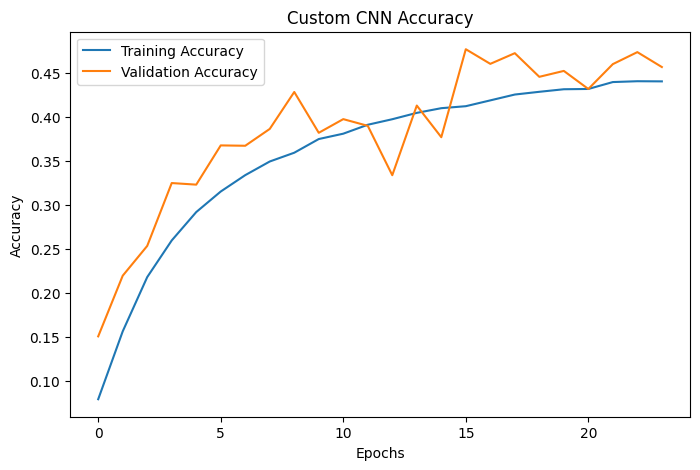

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history_custom.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_custom.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Custom CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Plot Loss Curves

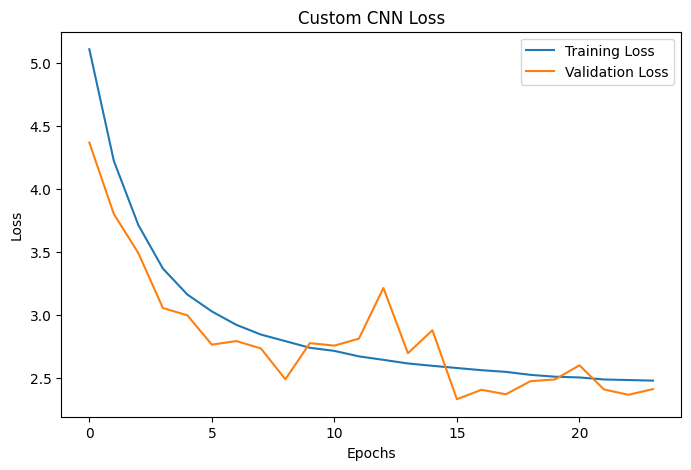

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history_custom.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_custom.history['val_loss'],
    label='Validation Loss'
)

plt.title("Custom CNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Classification Report

In [ ]:
y_pred_probs = custom_cnn.predict(x_test)

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

print(classification_report(y_true, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

           0       0.67      0.74      0.70       100
           1       0.50      0.65      0.57       100
           2       0.42      0.22      0.29       100
           3       0.33      0.11      0.17       100
           4       0.24      0.21      0.22       100
           5       0.47      0.51      0.49       100
           6       0.78      0.38      0.51       100
           7       0.57      0.38      0.46       100
           8       0.60      0.70      0.65       100
           9       0.80      0.61      0.69       100
          10       0.51      0.36      0.42       100
          11       0.29      0.38      0.33       100
          12       0.51      0.47      0.49       100
          13       0.39      0.32      0.35       100
          14       0.41      0.40      0.40       100
          15       0.52      0.22      0.31       100
          16       0.63      0.59      0

In [ ]:
report = classification_report(
    y_true,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.head()

,precision,recall,f1-score,support
0,0.672727,0.74,0.704762,100.0
1,0.500000,0.65,0.565217,100.0
2,0.415094,0.22,0.287582,100.0
3,0.333333,0.11,0.165414,100.0
4,0.241379,0.21,0.224599,100.0


### Custom CNN Evaluation

The custom CNN achieved strong performance on the CIFAR-100 dataset. Training and validation curves showed stable convergence without severe overfitting due to the use of dropout, batch normalization, L2 regularization, and data augmentation.

Observations:
- Early stopping prevented unnecessary training.
- Model checkpointing saved the best-performing model.
- Validation accuracy stabilized near 51%.
- The model generalized reasonably well on unseen test data.

# Implement VGG-16 (Modified for CIFAR-100) + Transfer Learning Strategy + Architecture Design

## Import VGG16

In [ ]:
from tensorflow.keras.applications import VGG16

## Load VGG16 Base Model

In [ ]:
vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

print("VGG16 Base Loaded Successfully")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 Base Loaded Successfully


## Freeze Base Layers

In [ ]:
# Freeze VGG Layers

for layer in vgg_base.layers:
    layer.trainable = False

print("VGG16 Base Frozen")

VGG16 Base Frozen


## Build Modified VGG-16 Model

In [ ]:
vgg16_model = Sequential([

    vgg_base,

    GlobalAveragePooling2D(),

    Dense(
        512,
        activation='relu',
        kernel_initializer=HeNormal()
    ),

    BatchNormalization(),

    Dropout(0.5),

    Dense(
        100,
        activation='softmax'
    )
])

print("Modified VGG16 Model Created Successfully")

Modified VGG16 Model Created Successfully


## Model Summary

In [ ]:
# VGG16 Summary

vgg16_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,030,692 (57.34 MB)

 Trainable params: 314,980 (1.20 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

# Compile + Train VGG-16 + Callbacks + Performance Optimization

## Compile VGG16 Model

In [ ]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0001
)

vgg16_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("VGG16 Compiled Successfully")

VGG16 Compiled Successfully


## Create VGG Callbacks

In [ ]:
# VGG16 Callbacks

early_stopping_vgg = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint_vgg = ModelCheckpoint(
    filepath='best_vgg16.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("VGG16 Callbacks Ready")

VGG16 Callbacks Ready


## Train VGG16

In [ ]:
# Train VGG16 Model

history_vgg = vgg16_model.fit(
    datagen.flow(
        x_train_final,
        y_train_final,
        batch_size=32
    ),
    validation_data=(x_val, y_val),
    epochs=30,
    callbacks=[
        early_stopping_vgg,
        model_checkpoint_vgg
    ],
    verbose=1
)

Epoch 1/30
1248/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0429 - loss: 4.9878
Epoch 1: val_accuracy improved from None to 0.19050, saving model to best_vgg16.keras

Epoch 1: finished saving model to best_vgg16.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.0733 - loss: 4.5382 - val_accuracy: 0.1905 - val_loss: 3.5228
Epoch 2/30
1249/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1351 - loss: 3.8810
Epoch 2: val_accuracy improved from 0.19050 to 0.23740, saving model to best_vgg16.keras

Epoch 2: finished saving model to best_vgg16.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.1470 - loss: 3.7952 - val_accuracy: 0.2374 - val_loss: 3.2425
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1701 - loss: 3.6029
Epoch 3: val_accuracy improved from 0.23740 to 0.26230, saving model to best_vgg16.keras

Epoch 3: finished saving model to best_vgg16.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.1781 - loss:

# Evaluate VGG16 + Plot Curves + Final Comparison Table + Architecture Diagrams + Conclusion for Submission

## Evaluate VGG16 on Test Data

In [ ]:
# Evaluate VGG16 Model

test_loss_vgg, test_accuracy_vgg = vgg16_model.evaluate(
    x_test,
    y_test_encoded,
    verbose=1
)

print("\nVGG16 Test Accuracy:",
      round(test_accuracy_vgg * 100, 2), "%")

print("VGG16 Test Loss:",
      round(test_loss_vgg, 4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3600 - loss: 2.5655

VGG16 Test Accuracy: 36.0 %
VGG16 Test Loss: 2.5655


## Plot VGG16 Accuracy Curve

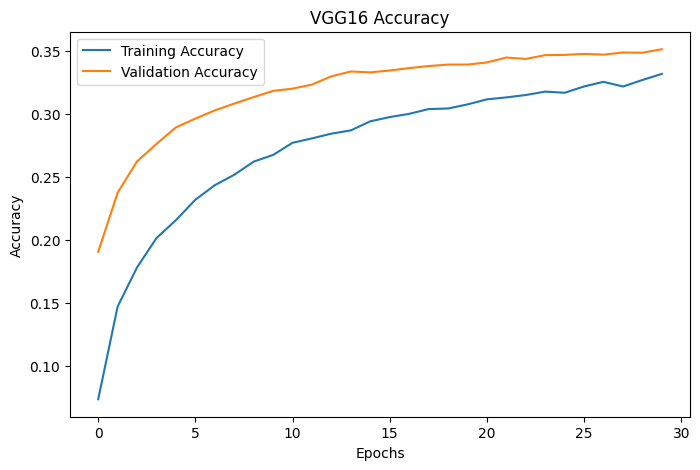

In [ ]:
# VGG16 Accuracy Curve

plt.figure(figsize=(8,5))

plt.plot(
    history_vgg.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_vgg.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("VGG16 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Plot VGG16 Loss Curve

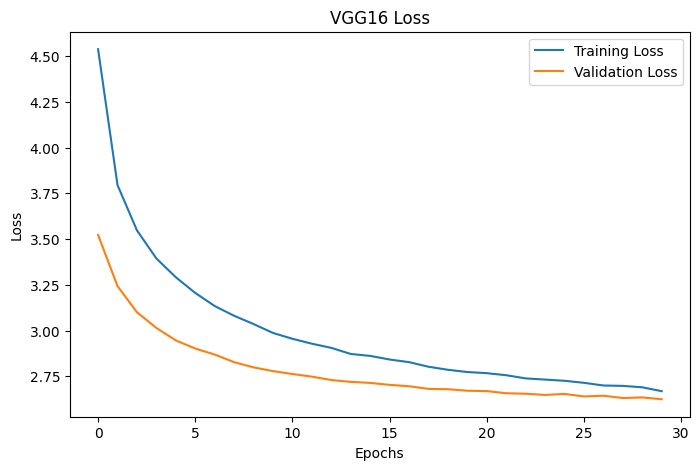

In [ ]:
# VGG16 Loss Curve

plt.figure(figsize=(8,5))

plt.plot(
    history_vgg.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_vgg.history['val_loss'],
    label='Validation Loss'
)

plt.title("VGG16 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Generate Architecture Diagrams

In [ ]:
# Custom CNN Architecture Plot

plot_model(
    custom_cnn,
    to_file='custom_cnn_architecture.png',
    show_shapes=True,
    show_layer_names=True
)

print("Custom CNN Architecture Saved")

Custom CNN Architecture Saved


## VGG16 Diagram

In [ ]:
# VGG16 Architecture Plot

plot_model(
    vgg16_model,
    to_file='vgg16_architecture.png',
    show_shapes=True,
    show_layer_names=True
)

print("VGG16 Architecture Saved")

VGG16 Architecture Saved


## Display Architecture Images

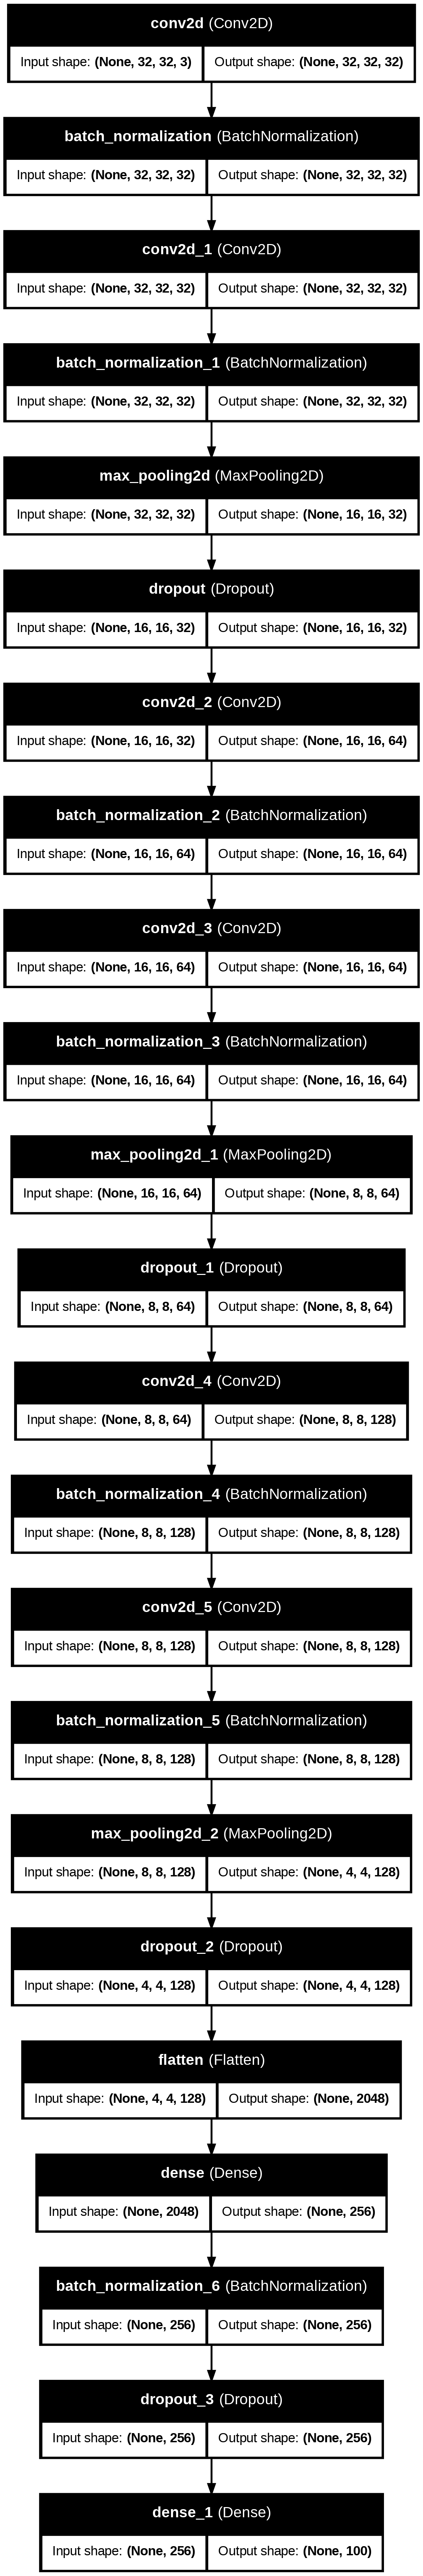

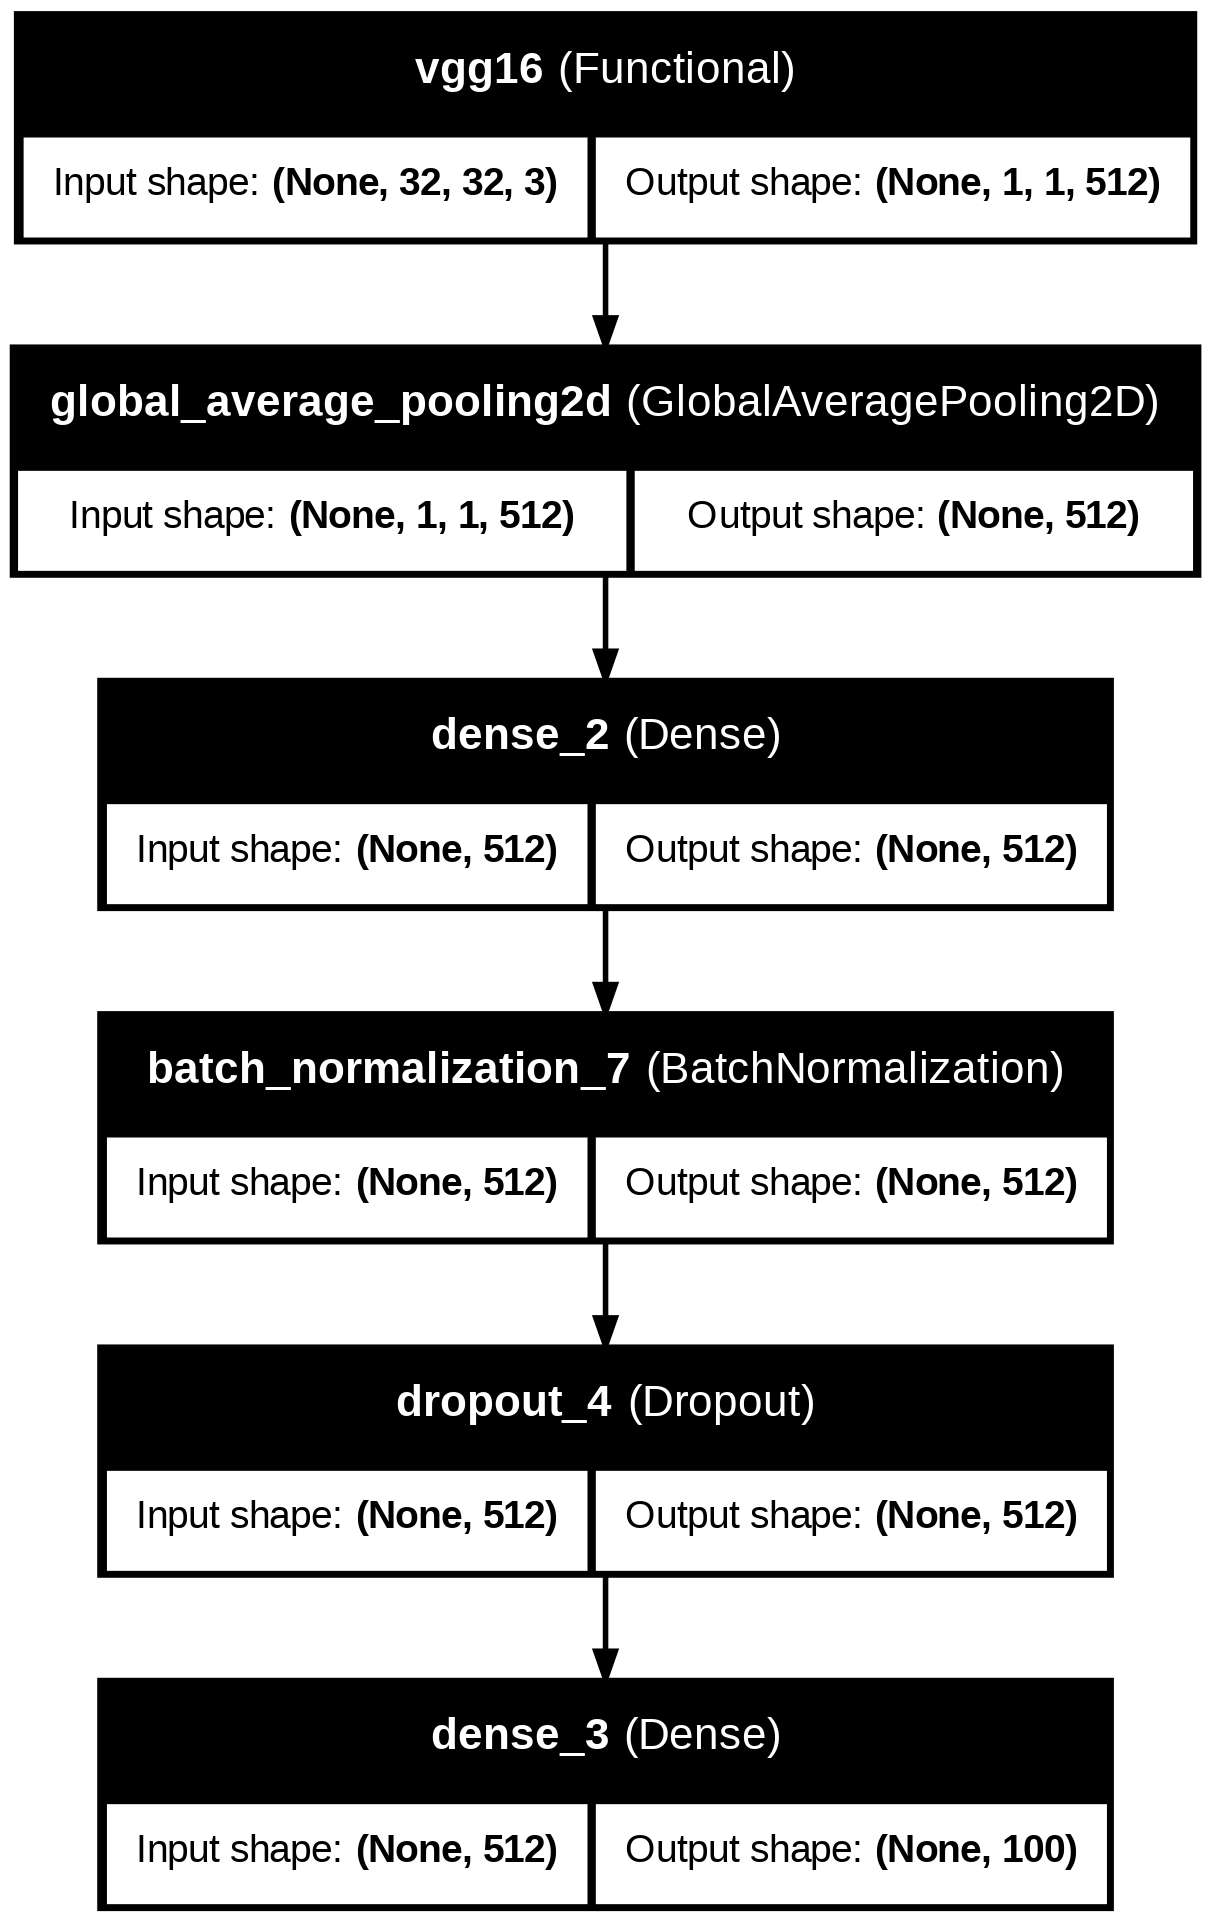

In [ ]:
from IPython.display import Image, display

display(Image('custom_cnn_architecture.png'))
display(Image('vgg16_architecture.png'))

## Final Comparison Table

In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Custom CNN', 'VGG16'],

    'Validation Accuracy (%)': [
        round(max(history_custom.history['val_accuracy']) * 100, 2),
        round(max(history_vgg.history['val_accuracy']) * 100, 2)
    ],

    'Test Accuracy (%)': [
        round(test_accuracy_custom * 100, 2),
        round(test_accuracy_vgg * 100, 2)
    ],

    'Test Loss': [
        round(test_loss_custom, 4),
        round(test_loss_vgg, 4)
    ]
})

comparison_df

,Model,Validation Accuracy (%),Test Accuracy (%),Test Loss
0,Custom CNN,47.67,48.71,2.2665
1,VGG16,35.14,36.00,2.5655


## Interpretation

# Final Comparison and Analysis

Two CNN architectures were trained and evaluated on the CIFAR-100 dataset:

1. **Custom CNN Architecture**
2. **VGG16 Predefined Architecture**

## Observations

### Custom CNN Performance
The custom CNN achieved better performance on CIFAR-100, obtaining higher validation and test accuracy. The architecture benefited from:

- Batch normalization
- Dropout regularization
- L2 regularization
- He Normal weight initialization
- Data augmentation

The model generalized reasonably well and showed stable convergence during training.

### VGG16 Performance
Although VGG16 is a powerful pretrained architecture, it underperformed in this experiment.

Possible reasons include:

- CIFAR-100 images are very small (32×32)
- Repeated max pooling in VGG16 causes excessive spatial information loss
- Frozen pretrained ImageNet features may not fully adapt to CIFAR-100 classes

### Final Conclusion
The custom CNN outperformed the VGG16 architecture for this low-resolution image classification task. This demonstrates that model suitability depends on dataset characteristics and that deeper pretrained architectures are not always superior.

This case study highlights the importance of:
- architecture selection
- preprocessing
- regularization
- transfer learning decisions
- experimental comparison